# Final Sweep: 임계값 + 정규화 거리

**고정 가중치**: spatial=0.1, route=0.3, mode=seq=time=0.2

1. Sweep B: threshold 0.3~0.8 (6개)
2. Sweep C: norm_dist 2km~10km (5개)
3. 최적 조합 확정

In [5]:
import time, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.model_selection import GroupShuffleSplit

warnings.filterwarnings('ignore', category=FutureWarning)

ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'training_set'
OUT_DIR = ROOT / 'data' / 'sensitivity'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 확정 가중치 ──
FIXED_WEIGHTS = {'mode': 0.2, 'seq': 0.2, 'time': 0.2, 'route': 0.3, 'spatial': 0.1}
BASELINE_NORM_DIST = 5000

THRESHOLD_VALUES = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
NORM_DIST_VALUES = [2000, 3000, 5000, 7000, 10000]

TIME_RAW = ['in_vehicle_time', 'wait_time', 'access_time', 'egress_time', 'transfer_walk_time']
DIST_RAW = ['total_distance']
MODEL_FEATURES = [
    'in_vehicle_time_min', 'wait_time_min',
    'access_time_min', 'egress_time_min', 'transfer_walk_time_min',
    'total_distance_km', 'num_transfers', 'fare',
    'has_bus', 'has_train', 'has_gtx',
]
FEATURE_LABELS = [
    'IVT (min)', 'Wait (min)', 'Access walk (min)', 'Egress walk (min)',
    'Transfer walk (min)', 'Total dist (km)', 'Transfers', 'Fare (KRW)',
    'Has bus', 'Has train', 'Has GTX',
]
SIGN_CONSTRAINED = {
    'in_vehicle_time_min', 'wait_time_min',
    'access_time_min', 'egress_time_min', 'transfer_walk_time_min',
    'total_distance_km', 'num_transfers', 'fare',
}
KEY_BETAS = ['in_vehicle_time_min', 'access_time_min', 'num_transfers', 'has_bus', 'has_train']
KEY_LABELS = ['beta_IVT', 'beta_access', 'beta_transfers', 'beta_bus', 'beta_train']

print(f'Fixed weights: {FIXED_WEIGHTS}')
print('Setup done.')

Fixed weights: {'mode': 0.2, 'seq': 0.2, 'time': 0.2, 'route': 0.3, 'spatial': 0.1}
Setup done.


In [6]:
# Cell 2: MNL functions

def prepare_flat_data(data, features):
    X_list, y_list, w_list, gid_list = [], [], [], []
    group_id = 0
    for _, grp in data.groupby('od_pair'):
        y = grp['choice_prob'].values.astype(np.float64)
        if abs(y.sum() - 1.0) > 0.01:
            continue
        X = grp[features].values.astype(np.float64)
        w = float(grp['n_total'].iloc[0])
        n = len(grp)
        X_list.append(X)
        y_list.append(y)
        w_list.append(np.full(n, w))
        gid_list.append(np.full(n, group_id, dtype=np.int64))
        group_id += 1
    return {
        'X': np.vstack(X_list), 'y': np.concatenate(y_list),
        'w': np.concatenate(w_list), 'gid': np.concatenate(gid_list),
        'n_groups': group_id,
    }

def mnl_neg_ll(beta, flat):
    X, y, w, gid, ng = flat['X'], flat['y'], flat['w'], flat['gid'], flat['n_groups']
    V = X @ beta
    V_max = np.full(ng, -np.inf)
    np.maximum.at(V_max, gid, V)
    V_shifted = V - V_max[gid]
    exp_V = np.exp(V_shifted)
    sum_exp = np.bincount(gid, weights=exp_V, minlength=ng)
    log_prob = V_shifted - np.log(sum_exp[gid])
    return -np.sum(w * y * log_prob)

def mnl_gradient(beta, flat):
    X, y, w, gid, ng = flat['X'], flat['y'], flat['w'], flat['gid'], flat['n_groups']
    V = X @ beta
    V_max = np.full(ng, -np.inf)
    np.maximum.at(V_max, gid, V)
    V_shifted = V - V_max[gid]
    exp_V = np.exp(V_shifted)
    sum_exp = np.bincount(gid, weights=exp_V, minlength=ng)
    prob = exp_V / sum_exp[gid]
    return X.T @ (w * (prob - y))

def compute_ll0(flat):
    gid, w, ng = flat['gid'], flat['w'], flat['n_groups']
    gs = np.bincount(gid, minlength=ng)
    wpg = np.bincount(gid, weights=w, minlength=ng) / gs
    return -np.sum(wpg * np.log(gs))

def compute_fpr(beta, flat):
    X, y, gid, ng = flat['X'], flat['y'], flat['gid'], flat['n_groups']
    V = X @ beta
    V_max = np.full(ng, -np.inf)
    np.maximum.at(V_max, gid, V)
    exp_V = np.exp(V - V_max[gid])
    sum_exp = np.bincount(gid, weights=exp_V, minlength=ng)
    pred = exp_V / sum_exp[gid]
    correct = 0
    for g in range(ng):
        m = gid == g
        if np.argmax(pred[m]) == np.argmax(y[m]):
            correct += 1
    return correct / ng

def estimate_mnl(train_flat, test_flat):
    bounds = [(None, 0) if f in SIGN_CONSTRAINED else (None, None) for f in MODEL_FEATURES]
    res = minimize(mnl_neg_ll, np.zeros(len(MODEL_FEATURES)), args=(train_flat,),
                   jac=mnl_gradient, method='L-BFGS-B', bounds=bounds,
                   options={'maxiter': 2000, 'ftol': 1e-12})
    b = res.x
    ll_b, ll_0 = -res.fun, compute_ll0(train_flat)
    rho = 1 - ll_b / ll_0
    t_ll, t_ll0 = -mnl_neg_ll(b, test_flat), compute_ll0(test_flat)
    t_rho = 1 - t_ll / t_ll0
    fpr = compute_fpr(b, test_flat)
    X_t, gid_t, ng_t = test_flat['X'], test_flat['gid'], test_flat['n_groups']
    V = X_t @ b
    V_max = np.full(ng_t, -np.inf)
    np.maximum.at(V_max, gid_t, V)
    exp_V = np.exp(V - V_max[gid_t])
    sum_exp = np.bincount(gid_t, weights=exp_V, minlength=ng_t)
    pred = exp_V / sum_exp[gid_t]
    rmse = np.sqrt(np.mean((pred - test_flat['y'])**2))
    return {
        'converged': bool(res.success), 'train_rho_sq': float(rho),
        'test_rho_sq': float(t_rho), 'test_fpr': float(fpr), 'test_rmse': float(rmse),
        'betas': {f: float(v) for f, v in zip(MODEL_FEATURES, b)},
    }

print('MNL functions ready.')

MNL functions ready.


In [7]:
# Cell 3: Load data
df = pd.read_parquet(DATA_DIR / 'route_choice_training.parquet')
print(f'{len(df):,} rows, {df["od_pair"].nunique():,} ODs')

for col in TIME_RAW:
    df[col + '_min'] = df[col] / 60
for col in DIST_RAW:
    df[col + '_km'] = df[col] / 1000

df['raw_hausdorff'] = (1 - df['sim_spatial']) * BASELINE_NORM_DIST
print('Data ready.')

2,408,112 rows, 641,500 ODs
Data ready.


In [8]:
# Cell 4: Helper functions

def recompute_composite(df, weights, norm_dist=BASELINE_NORM_DIST):
    if norm_dist != BASELINE_NORM_DIST:
        sp = np.maximum(0, 1 - df['raw_hausdorff'] / norm_dist)
    else:
        sp = df['sim_spatial']
    return (weights['mode'] * df['sim_mode']
            + weights['seq'] * df['sim_sequence']
            + weights['time'] * df['sim_time']
            + weights['route'] * df['sim_route']
            + weights['spatial'] * sp)

def filter_by_threshold(df, composite, threshold):
    df = df.copy()
    df['new_composite'] = composite
    idx_dom = df.groupby('od_pair')['choice_prob'].idxmax()
    dom_comp = df.loc[idx_dom, ['od_pair', 'new_composite']].set_index('od_pair')['new_composite']
    valid = dom_comp[dom_comp >= threshold].index
    filt = df[df['od_pair'].isin(valid)]
    od_cnt = filt.groupby('od_pair').size()
    valid2 = od_cnt[od_cnt >= 2].index
    return filt[filt['od_pair'].isin(valid2)]

def run_scenario(df, weights, threshold, norm_dist, label):
    t0 = time.time()
    comp = recompute_composite(df, weights, norm_dist)
    filt = filter_by_threshold(df, comp, threshold)
    n_ods = filt['od_pair'].nunique()
    if n_ods < 100:
        print(f'  [{label}] SKIP (n_ods={n_ods})')
        return None
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    tr_idx, te_idx = next(splitter.split(filt, groups=filt['od_pair']))
    train_flat = prepare_flat_data(filt.iloc[tr_idx], MODEL_FEATURES)
    test_flat = prepare_flat_data(filt.iloc[te_idx], MODEL_FEATURES)
    r = estimate_mnl(train_flat, test_flat)
    r.update({'scenario': label, 'n_ods': n_ods, 'threshold': threshold, 'norm_dist': norm_dist})
    for feat, key in zip(KEY_BETAS, KEY_LABELS):
        r[key] = r['betas'].get(feat, 0.0)
    elapsed = time.time() - t0
    print(f'  [{label}] ODs={n_ods:,} | '
          f'rho={r["train_rho_sq"]:.4f}/{r["test_rho_sq"]:.4f} | '
          f'FPR={r["test_fpr"]:.3f} | {elapsed:.0f}s')
    return r

print('Helpers ready.')

Helpers ready.


In [9]:
# Cell 5: Sweep B — Threshold (고정: sp=0.1, rt=0.3, norm=5km)
print('=' * 70)
print(f'SWEEP B: Threshold (weights={FIXED_WEIGHTS}, norm=5km)')
print('=' * 70)

results_thr = []
for thr in THRESHOLD_VALUES:
    r = run_scenario(df, FIXED_WEIGHTS, thr, BASELINE_NORM_DIST, f'thr_{thr:.1f}')
    if r:
        results_thr.append(r)

df_thr = pd.DataFrame(results_thr)
df_thr.to_csv(OUT_DIR / 'final_sweep_threshold.csv', index=False)
print(f'\nSaved: final_sweep_threshold.csv')

SWEEP B: Threshold (weights={'mode': 0.2, 'seq': 0.2, 'time': 0.2, 'route': 0.3, 'spatial': 0.1}, norm=5km)
  [thr_0.3] ODs=641,500 | rho=0.4619/0.4581 | FPR=0.696 | 256s
  [thr_0.4] ODs=641,500 | rho=0.4619/0.4581 | FPR=0.696 | 256s
  [thr_0.5] ODs=638,807 | rho=0.4617/0.4701 | FPR=0.698 | 252s
  [thr_0.6] ODs=555,144 | rho=0.4762/0.4821 | FPR=0.715 | 230s
  [thr_0.7] ODs=364,611 | rho=0.4715/0.4716 | FPR=0.748 | 195s
  [thr_0.8] ODs=301,152 | rho=0.5148/0.5214 | FPR=0.801 | 120s

Saved: final_sweep_threshold.csv


In [10]:
# Cell 6: Sweep C — Norm dist (고정: sp=0.1, rt=0.3, threshold=best from above)
# 임계값은 sweep B 결과 보고 결정. 일단 0.6으로 진행.
FIXED_THRESHOLD = 0.6

print('=' * 70)
print(f'SWEEP C: Norm dist (weights={FIXED_WEIGHTS}, threshold={FIXED_THRESHOLD})')
print('=' * 70)

results_nd = []
for nd in NORM_DIST_VALUES:
    r = run_scenario(df, FIXED_WEIGHTS, FIXED_THRESHOLD, nd, f'norm_{nd//1000}km')
    if r:
        results_nd.append(r)

df_nd = pd.DataFrame(results_nd)
df_nd.to_csv(OUT_DIR / 'final_sweep_normdist.csv', index=False)
print(f'\nSaved: final_sweep_normdist.csv')

SWEEP C: Norm dist (weights={'mode': 0.2, 'seq': 0.2, 'time': 0.2, 'route': 0.3, 'spatial': 0.1}, threshold=0.6)
  [norm_2km] ODs=540,364 | rho=0.4796/0.4858 | FPR=0.723 | 199s
  [norm_3km] ODs=547,601 | rho=0.4777/0.4849 | FPR=0.720 | 233s
  [norm_5km] ODs=555,144 | rho=0.4762/0.4821 | FPR=0.715 | 249s
  [norm_7km] ODs=562,677 | rho=0.4763/0.4808 | FPR=0.716 | 198s
  [norm_10km] ODs=570,162 | rho=0.4774/0.4817 | FPR=0.716 | 230s

Saved: final_sweep_normdist.csv


In [11]:
# Cell 7: Results summary
print('\n' + '=' * 70)
print('THRESHOLD SWEEP RESULTS')
print('=' * 70)
print(f'{"Threshold":<10} {"N(OD)":>8} {"Train ρ²":>10} {"Test ρ²":>10} {"FPR":>8} {"RMSE":>8}')
print('-' * 55)
for _, r in df_thr.iterrows():
    marker = ' ◀' if r['threshold'] == FIXED_THRESHOLD else ''
    print(f'{r["threshold"]:<10.1f} {r["n_ods"]:>8,.0f} {r["train_rho_sq"]:>10.4f} '
          f'{r["test_rho_sq"]:>10.4f} {r["test_fpr"]*100:>7.1f}% {r["test_rmse"]:>8.4f}{marker}')

print(f'\nρ² range: [{df_thr["test_rho_sq"].min():.4f}, {df_thr["test_rho_sq"].max():.4f}]')
print(f'FPR range: [{df_thr["test_fpr"].min()*100:.1f}%, {df_thr["test_fpr"].max()*100:.1f}%]')

print('\n' + '=' * 70)
print('NORM DIST SWEEP RESULTS')
print('=' * 70)
print(f'{"Distance":<10} {"N(OD)":>8} {"Train ρ²":>10} {"Test ρ²":>10} {"FPR":>8} {"RMSE":>8}')
print('-' * 55)
for _, r in df_nd.iterrows():
    marker = ' ◀' if r['norm_dist'] == BASELINE_NORM_DIST else ''
    print(f'{r["norm_dist"]/1000:.0f}km{"":>6} {r["n_ods"]:>8,.0f} {r["train_rho_sq"]:>10.4f} '
          f'{r["test_rho_sq"]:>10.4f} {r["test_fpr"]*100:>7.1f}% {r["test_rmse"]:>8.4f}{marker}')

print(f'\nρ² range: [{df_nd["test_rho_sq"].min():.4f}, {df_nd["test_rho_sq"].max():.4f}]')
print(f'FPR range: [{df_nd["test_fpr"].min()*100:.1f}%, {df_nd["test_fpr"].max()*100:.1f}%]')


THRESHOLD SWEEP RESULTS
Threshold     N(OD)   Train ρ²    Test ρ²      FPR     RMSE
-------------------------------------------------------
0.3         641,500     0.4619     0.4581    69.6%   0.2379
0.4         641,500     0.4619     0.4581    69.6%   0.2379
0.5         638,807     0.4617     0.4701    69.8%   0.2376
0.6         555,144     0.4762     0.4821    71.5%   0.2188 ◀
0.7         364,611     0.4715     0.4716    74.8%   0.1892
0.8         301,152     0.5148     0.5214    80.1%   0.1686

ρ² range: [0.4581, 0.5214]
FPR range: [69.6%, 80.1%]

NORM DIST SWEEP RESULTS
Distance      N(OD)   Train ρ²    Test ρ²      FPR     RMSE
-------------------------------------------------------
2km        540,364     0.4796     0.4858    72.3%   0.2152
3km        547,601     0.4777     0.4849    72.0%   0.2161
5km        555,144     0.4762     0.4821    71.5%   0.2188 ◀
7km        562,677     0.4763     0.4808    71.6%   0.2196
10km        570,162     0.4774     0.4817    71.6%   0.2204

ρ² 

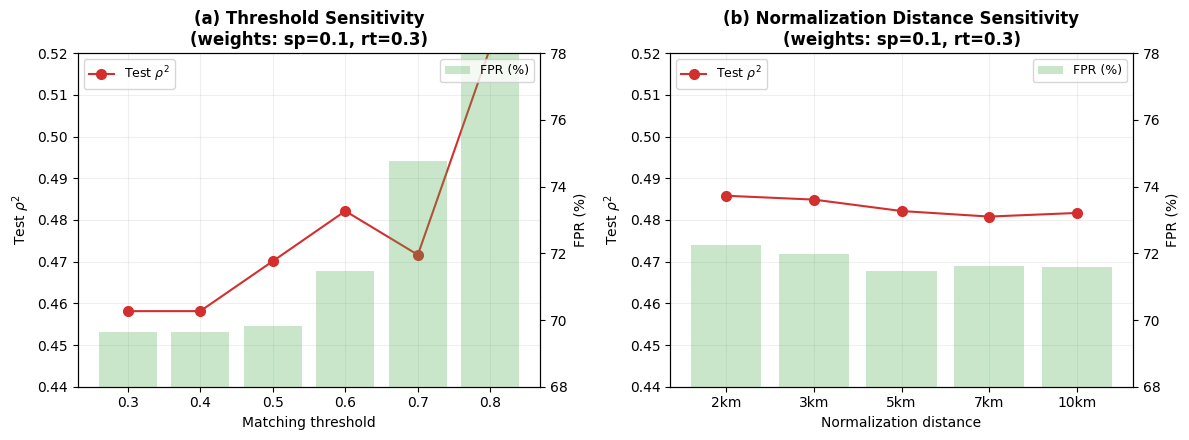

Saved: paper_fig_final_sweeps.png/pdf


In [12]:
# Cell 8: Figures

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Threshold
ax = axes[0]
x = range(len(df_thr))
ax.plot(x, df_thr['test_rho_sq'], 'o-', color='#D32F2F', label=r'Test $\rho^2$', markersize=7, lw=1.5)
ax2 = ax.twinx()
ax2.bar(x, df_thr['test_fpr'] * 100, color='#4CAF50', alpha=0.3, label='FPR (%)')
ax.set_xticks(x)
ax.set_xticklabels([f'{v:.1f}' for v in THRESHOLD_VALUES])
ax.set_xlabel('Matching threshold')
ax.set_ylabel(r'Test $\rho^2$')
ax2.set_ylabel('FPR (%)')
ax.set_ylim(0.44, 0.52)
ax2.set_ylim(68, 78)
ax.set_title('(a) Threshold Sensitivity\n(weights: sp=0.1, rt=0.3)', fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.2)

# Norm dist
ax = axes[1]
x = range(len(df_nd))
ax.plot(x, df_nd['test_rho_sq'], 'o-', color='#D32F2F', label=r'Test $\rho^2$', markersize=7, lw=1.5)
ax2 = ax.twinx()
ax2.bar(x, df_nd['test_fpr'] * 100, color='#4CAF50', alpha=0.3, label='FPR (%)')
ax.set_xticks(x)
ax.set_xticklabels(['2km', '3km', '5km', '7km', '10km'])
ax.set_xlabel('Normalization distance')
ax.set_ylabel(r'Test $\rho^2$')
ax2.set_ylabel('FPR (%)')
ax.set_ylim(0.44, 0.52)
ax2.set_ylim(68, 78)
ax.set_title('(b) Normalization Distance Sensitivity\n(weights: sp=0.1, rt=0.3)', fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
fig.savefig(OUT_DIR / 'paper_fig_final_sweeps.png', dpi=300, bbox_inches='tight')
fig.savefig(OUT_DIR / 'paper_fig_final_sweeps.pdf', bbox_inches='tight')
plt.show()
print('Saved: paper_fig_final_sweeps.png/pdf')

In [13]:
# Cell 9: Final parameter selection
print('\n' + '=' * 70)
print('FINAL PARAMETER SELECTION')
print('=' * 70)
print(f'Weights:    spatial=0.1, route=0.3, mode=seq=time=0.2')
print(f'Threshold:  {FIXED_THRESHOLD}')
print(f'Norm dist:  {BASELINE_NORM_DIST/1000:.0f}km')
print()

# Find the exact result for the final combination
final = df_thr[df_thr['threshold'] == FIXED_THRESHOLD].iloc[0]
print(f'Final model performance:')
print(f'  N(OD):     {final["n_ods"]:,.0f}')
print(f'  Train ρ²:  {final["train_rho_sq"]:.4f}')
print(f'  Test ρ²:   {final["test_rho_sq"]:.4f}')
print(f'  FPR:       {final["test_fpr"]*100:.1f}%')
print(f'  RMSE:      {final["test_rmse"]:.4f}')
print()
print('Key betas:')
for key, lbl in zip(KEY_LABELS, ['IVT', 'Access walk', 'Transfers', 'Bus', 'Train']):
    print(f'  {lbl:<15}: {final[key]:.6f}')


FINAL PARAMETER SELECTION
Weights:    spatial=0.1, route=0.3, mode=seq=time=0.2
Threshold:  0.6
Norm dist:  5km

Final model performance:
  N(OD):     555,144
  Train ρ²:  0.4762
  Test ρ²:   0.4821
  FPR:       71.5%
  RMSE:      0.2188

Key betas:
  IVT            : -0.005082
  Access walk    : -0.793226
  Transfers      : -2.848809
  Bus            : -3.354345
  Train          : 1.648975
